In [2]:
import pandas as pd
data = pd.read_csv('problem_8_token_confs.csv')
data.head()

,problem_id,attempt,answer,is_correct,token_index,token_confidence
0,8,4,1,1,0,24.700000
1,8,4,1,1,1,31.456250
2,8,4,1,1,2,20.240625
3,8,4,1,1,3,9.037563
4,8,4,1,1,4,9.132511


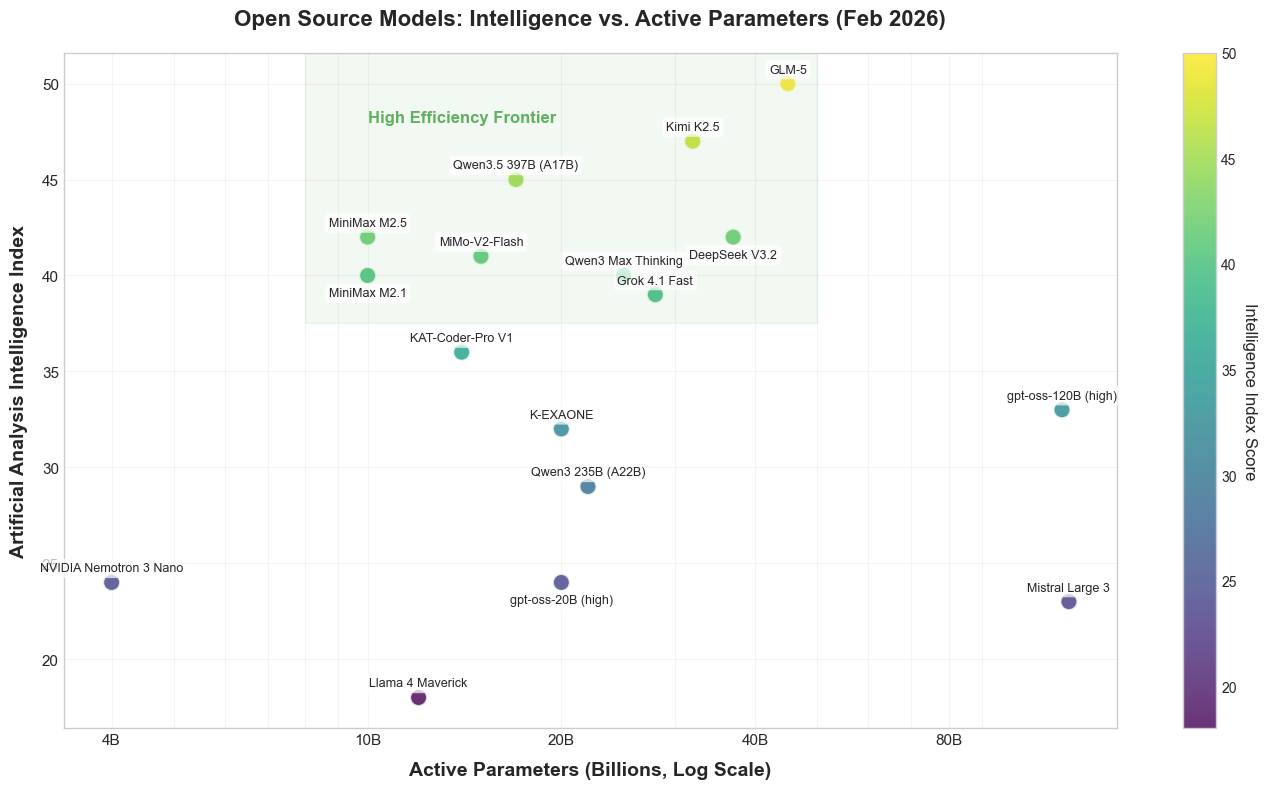

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data: Artificial Analysis Intelligence Index v4.0 (Feb 2026)
# Format: (Model Name, Active Params in Billions, Index Score, Organization)
models = [
    ("GLM-5", 45, 50, "Z AI"),
    ("Kimi K2.5", 32, 47, "Moonshot"),
    ("Qwen3.5 397B (A17B)", 17, 45, "Alibaba"),
    ("DeepSeek V3.2", 37, 42, "DeepSeek"),
    ("MiniMax M2.5", 10, 42, "MiniMax"),
    ("MiMo-V2-Flash", 15, 41, "Xiaomi"),
    ("Qwen3 Max Thinking", 25, 40, "Alibaba"), # Est active based on series
    ("MiniMax M2.1", 10, 40, "MiniMax"),
    ("Grok 4.1 Fast", 28, 39, "xAI"), # Est active
    ("KAT-Coder-Pro V1", 14, 36, "KwaiKAT"),
    ("gpt-oss-120B (high)", 120, 33, "OpenAI (OSS)"),
    ("K-EXAONE", 20, 32, "LG AI"),
    ("Qwen3 235B (A22B)", 22, 29, "Alibaba"),
    ("NVIDIA Nemotron 3 Nano", 4, 24, "NVIDIA"),
    ("gpt-oss-20B (high)", 20, 24, "OpenAI (OSS)"),
    ("Mistral Large 3", 123, 23, "Mistral"),
    ("Llama 4 Maverick", 12, 18, "Meta"),
]

# Extract data
names = [m[0] for m in models]
params = [m[1] for m in models]
scores = [m[2] for m in models]
orgs = [m[3] for m in models]

# Create Plot
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Scatter plot
scatter = plt.scatter(params, scores, c=scores, cmap='viridis', s=150, alpha=0.8, edgecolors='w', linewidth=1.5)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Intelligence Index Score', rotation=270, labelpad=15, fontsize=12)

# Log scale for X-axis (Active Parameters)
plt.xscale('log')

# Customizing ticks for log scale
plt.xticks([4, 10, 20, 40, 80, 150], ['4B', '10B', '20B', '40B', '80B', '150B'], fontsize=11)
plt.yticks(fontsize=11)

# Labels and Title
plt.xlabel('Active Parameters (Billions, Log Scale)', fontsize=14, labelpad=10, fontweight='bold')
plt.ylabel('Artificial Analysis Intelligence Index', fontsize=14, labelpad=10, fontweight='bold')
plt.title('Open Source Models: Intelligence vs. Active Parameters (Feb 2026)', fontsize=16, fontweight='bold', pad=20)

# Annotate points
# Adjusting text positions to avoid overlap (simple heuristic)
for i, txt in enumerate(names):
    y_offset = 1.2
    if txt in ["DeepSeek V3.2", "MiniMax M2.1", "gpt-oss-20B (high)"]:
        y_offset = -2.5
    
    plt.annotate(txt, (params[i], scores[i]), 
                 xytext=(0, 8 if y_offset > 0 else -15), 
                 textcoords='offset points', 
                 ha='center', 
                 fontsize=9, 
                 fontweight='medium',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))

# Highlight the "Efficient Frontier" (High Score, Low Params)
# Draw a shaded region for the top quadrant
plt.axvspan(8, 50, ymin=0.6, ymax=1, color='green', alpha=0.05)
plt.text(10, 48, "High Efficiency Frontier", color='green', fontsize=12, fontweight='bold', alpha=0.6)

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

# Show plot
plt.show()

In [3]:
# Check data types
print(data.dtypes)

# Check for string values in each column
for col in data.columns:
    string_mask = data[col].apply(lambda x: isinstance(x, str))
    if string_mask.any():
        print(f"Column '{col}' has string entries at indices: {data[string_mask].index.tolist()[:10]}")  # show first 10

# Omit rows with any string entries
data = data[~data.applymap(lambda x: isinstance(x, str)).any(axis=1)]

print(f"Data shape after omitting strings: {data.shape}")

problem_id            int64
attempt               int64
answer                int64
is_correct            int64
token_index           int64
token_confidence    float64
dtype: object


C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\2903816569.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data[~data.applymap(lambda x: isinstance(x, str)).any(axis=1)]


Data shape after omitting strings: (406315, 6)


In [5]:
data["is_correct"].value_counts()

is_correct
-1    187600
 1    109769
 0    108946
Name: count, dtype: int64

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\2151107944.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df.groupby(['attempt', 'window_idx']).apply(window_agg).reset_index()


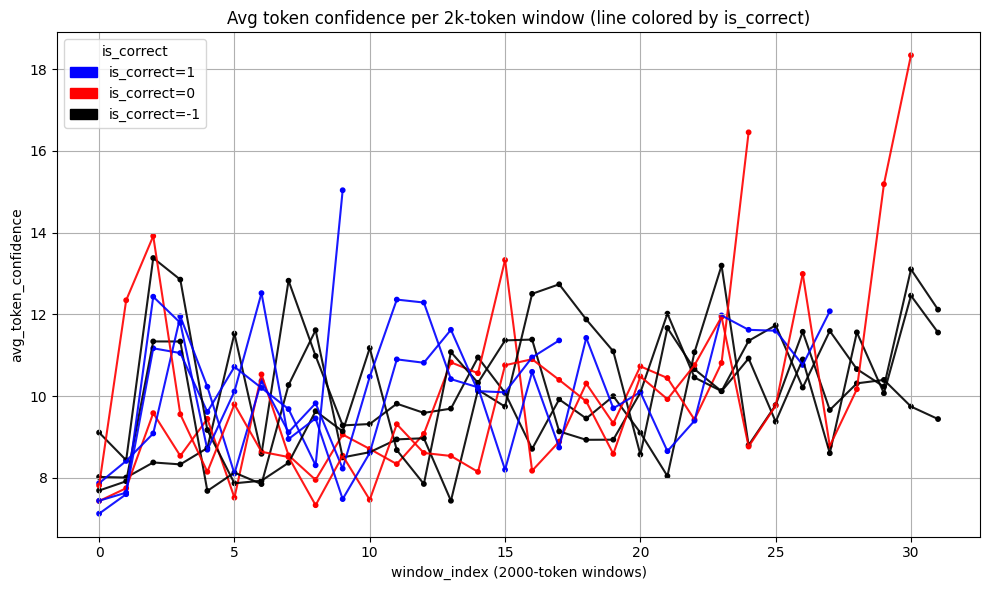


Aggregated windows sample:
   attempt  window_idx  avg_conf   count  is_correct_mode
0        1           0  8.018914  2000.0             -1.0
1        1           1  8.004416  2000.0             -1.0
2        1           2  8.373762  2000.0             -1.0
3        1           3  8.326720  2000.0             -1.0
4        1           4  8.726898  2000.0             -1.0


C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\2151107944.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_attempt = df.groupby('attempt').apply(


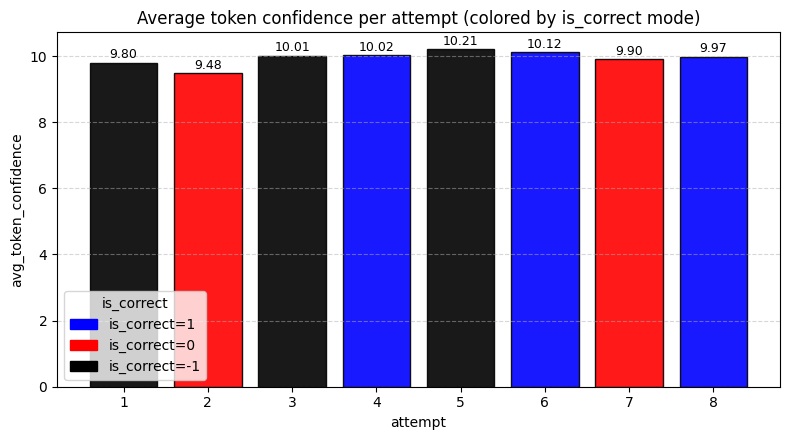


Aggregated attempts:
   attempt   avg_conf    count  is_correct_mode  color
0        1   9.800235  62048.0             -1.0  black
1        2   9.479206  48647.0              0.0    red
2        3  10.007958  63291.0             -1.0  black
3        4  10.022554  19755.0              1.0   blue
4        5  10.209492  62261.0             -1.0  black
5        6  10.117099  55525.0              1.0   blue
6        7   9.904655  60299.0              0.0    red
7        8   9.974986  34489.0              1.0   blue


In [9]:
# Aggregate avg confidence per 2000-token window and plot colored line segments by is_correct
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

window_size = 2000

df = data.copy()
# ensure token_index numeric
df['token_index'] = df['token_index'].astype(int)
# compute window index
df['window_idx'] = (df['token_index'] // window_size).astype(int)

# aggregate per attempt and window
def window_agg(g):
    mode = g['is_correct'].mode()
    mode_val = int(mode.iloc[0]) if not mode.empty else 0
    return pd.Series({'avg_conf': g['token_confidence'].mean(), 'count': len(g), 'is_correct_mode': mode_val})

agg = df.groupby(['attempt', 'window_idx']).apply(window_agg).reset_index()

# Map colors: 1->blue, -1->black, 0->red
color_map = {1: 'blue', -1: 'black', 0: 'red'}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for att, grp in agg.groupby('attempt'):
    grp = grp.sort_values('window_idx')
    x = grp['window_idx'].values
    y = grp['avg_conf'].values
    if len(x) < 2:
        # draw single point if only one window
        ax.scatter(x, y, c=[color_map.get(v, 'gray') for v in grp['is_correct_mode']], s=20)
        continue
    # build line segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    # color each segment by the is_correct_mode of the destination point
    seg_colors = [color_map.get(v, 'gray') for v in grp['is_correct_mode'].iloc[1:]]
    lc = LineCollection(segments, colors=seg_colors, linewidths=1.5, alpha=0.9)
    ax.add_collection(lc)
    # draw small markers at window points colored by is_correct_mode
    ax.scatter(x, y, c=[color_map.get(v, 'gray') for v in grp['is_correct_mode']], s=10)

# create legend for is_correct colors
from matplotlib.patches import Patch
handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]

plt.xlabel('window_index (2000-token windows)')
plt.ylabel('avg_token_confidence')
plt.title('Avg token confidence per 2k-token window (line colored by is_correct)')
plt.legend(handles=handles, title='is_correct')
plt.grid(True)
plt.tight_layout()
plt.savefig('avg_conf_per_2k_window_colored_by_is_correct_lines.png', dpi=150, bbox_inches='tight')
plt.show()

# print a small sample of aggregated data
print('\nAggregated windows sample:')
print(agg.head())

# --- New: average confidence per attempt (across all tokens) colored by is_correct mode ---
agg_attempt = df.groupby('attempt').apply(
    lambda g: pd.Series({
        'avg_conf': g['token_confidence'].mean(),
        'count': len(g),
        'is_correct_mode': int(g['is_correct'].mode().iloc[0]) if not g['is_correct'].mode().empty else 0
    })
).reset_index()

agg_attempt['color'] = agg_attempt['is_correct_mode'].map(color_map).fillna('gray')

plt.figure(figsize=(8, 4.5))
plt.bar(agg_attempt['attempt'], agg_attempt['avg_conf'], color=agg_attempt['color'], edgecolor='k', alpha=0.9)
for _, row in agg_attempt.iterrows():
    plt.text(row['attempt'], row['avg_conf'] + 0.05, f"{row['avg_conf']:.2f}", ha='center', va='bottom', fontsize=9)

plt.xlabel('attempt')
plt.ylabel('avg_token_confidence')
plt.title('Average token confidence per attempt (colored by is_correct mode)')
handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('avg_conf_by_attempt_colored_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAggregated attempts:')
print(agg_attempt)

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\434829147.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_std = df.groupby('attempt').apply(


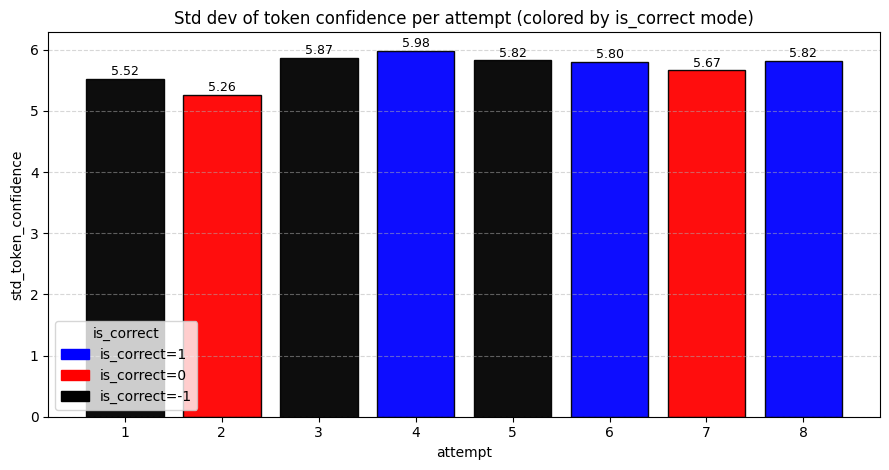


Per-attempt std summary:
   attempt  std_conf    count  is_correct_mode  color
0        1  5.522983  62048.0             -1.0  black
1        2  5.262818  48647.0              0.0    red
2        3  5.865960  63291.0             -1.0  black
3        4  5.983842  19755.0              1.0   blue
4        5  5.824252  62261.0             -1.0  black
5        6  5.803675  55525.0              1.0   blue
6        7  5.665283  60299.0              0.0    red
7        8  5.816869  34489.0              1.0   blue


In [10]:
# Plot std dev of token confidence per attempt, colored by is_correct mode
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

agg_std = df.groupby('attempt').apply(
    lambda g: pd.Series({
        'std_conf': g['token_confidence'].std(),
        'count': len(g),
        'is_correct_mode': int(g['is_correct'].mode().iloc[0]) if not g['is_correct'].mode().empty else 0
    })
).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_std['color'] = agg_std['is_correct_mode'].map(color_map).fillna('gray')

plt.figure(figsize=(9, 4.8))
plt.bar(agg_std['attempt'], agg_std['std_conf'], color=agg_std['color'], edgecolor='k', alpha=0.95)
for _, row in agg_std.iterrows():
    plt.text(row['attempt'], row['std_conf'] + 0.01, f"{row['std_conf']:.2f}", ha='center', va='bottom', fontsize=9)

handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.xlabel('attempt')
plt.ylabel('std_token_confidence')
plt.title('Std dev of token confidence per attempt (colored by is_correct mode)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('std_conf_by_attempt_colored_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-attempt std summary:')
print(agg_std)

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\1861287037.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg4k = df.groupby(['attempt', 'window_idx_4k']).apply(window_std).reset_index()


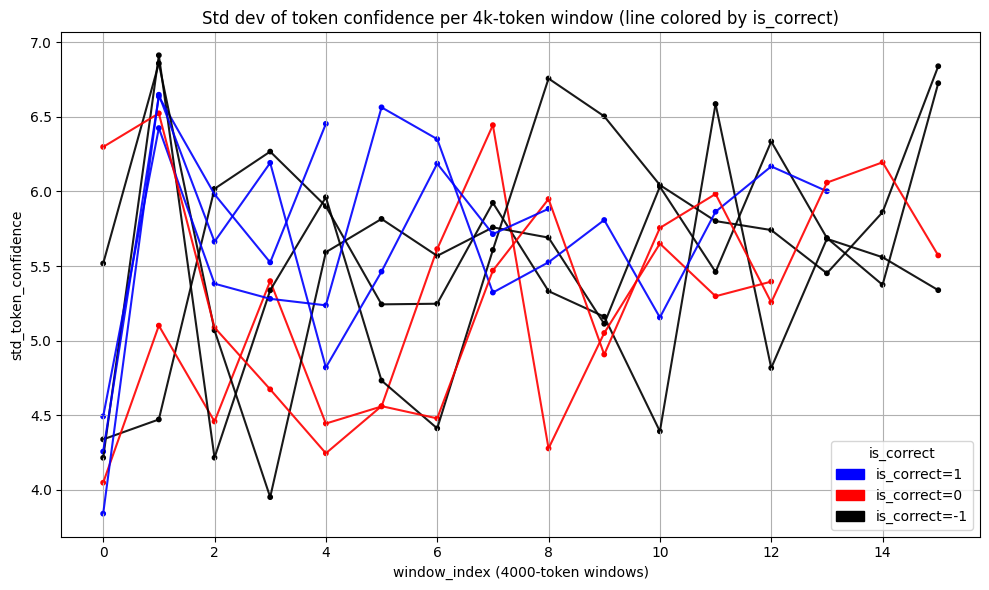


Sample aggregated 4k-window std:
   attempt  window_idx_4k  std_conf   count  is_correct_mode
0        1              0  4.336975  4000.0             -1.0
1        1              1  4.470521  4000.0             -1.0
2        1              2  6.018141  4000.0             -1.0
3        1              3  6.267747  4000.0             -1.0
4        1              4  5.900996  4000.0             -1.0


In [11]:
# Std dev of token confidence per 4000-token window, plotted like the avg-confidence line plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch

window_size = 4000

df = data.copy()
# ensure token_index numeric
df['token_index'] = df['token_index'].astype(int)
# compute 4k window index
df['window_idx_4k'] = (df['token_index'] // window_size).astype(int)

# aggregate per attempt and 4k window
def window_std(g):
    mode = g['is_correct'].mode()
    mode_val = int(mode.iloc[0]) if not mode.empty else 0
    return pd.Series({'std_conf': g['token_confidence'].std(), 'count': len(g), 'is_correct_mode': mode_val})

agg4k = df.groupby(['attempt', 'window_idx_4k']).apply(window_std).reset_index()

# Map colors: 1->blue, -1->black, 0->red
color_map = {1: 'blue', -1: 'black', 0: 'red'}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for att, grp in agg4k.groupby('attempt'):
    grp = grp.sort_values('window_idx_4k')
    x = grp['window_idx_4k'].values
    y = grp['std_conf'].values
    if len(x) < 2:
        ax.scatter(x, y, c=[color_map.get(v, 'gray') for v in grp['is_correct_mode']], s=20)
        continue
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_colors = [color_map.get(v, 'gray') for v in grp['is_correct_mode'].iloc[1:]]
    lc = LineCollection(segments, colors=seg_colors, linewidths=1.5, alpha=0.9)
    ax.add_collection(lc)
    ax.scatter(x, y, c=[color_map.get(v, 'gray') for v in grp['is_correct_mode']], s=10)

handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.xlabel('window_index (4000-token windows)')
plt.ylabel('std_token_confidence')
plt.title('Std dev of token confidence per 4k-token window (line colored by is_correct)')
plt.legend(handles=handles, title='is_correct')
plt.grid(True)
plt.tight_layout()
plt.savefig('std_conf_per_4k_window_colored_by_is_correct_lines.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSample aggregated 4k-window std:')
print(agg4k.head())

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\464177453.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_min = df.groupby('attempt').apply(


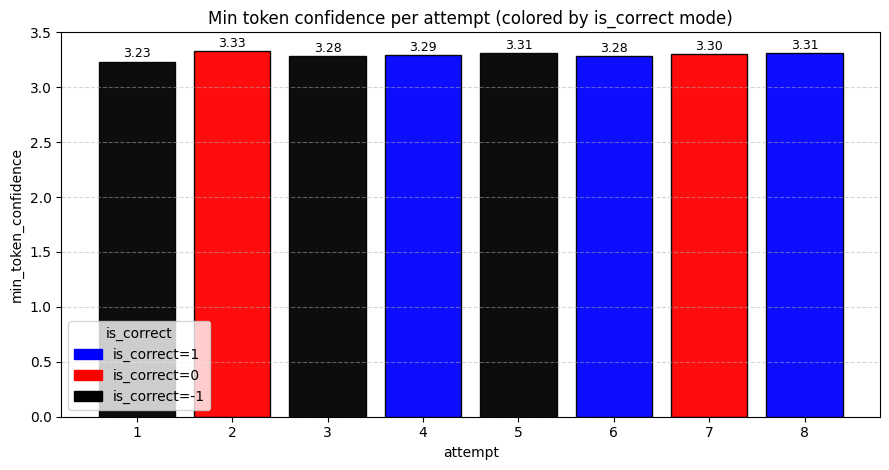


Per-attempt min summary:
   attempt  min_conf    count  is_correct_mode  color
0        1  3.234581  62048.0             -1.0  black
1        2  3.333601  48647.0              0.0    red
2        3  3.282344  63291.0             -1.0  black
3        4  3.289597  19755.0              1.0   blue
4        5  3.314772  62261.0             -1.0  black
5        6  3.283711  55525.0              1.0   blue
6        7  3.303905  60299.0              0.0    red
7        8  3.312373  34489.0              1.0   blue


In [12]:
# Min token confidence per attempt, colored by is_correct mode
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

agg_min = df.groupby('attempt').apply(
    lambda g: pd.Series({
        'min_conf': g['token_confidence'].min(),
        'count': len(g),
        'is_correct_mode': int(g['is_correct'].mode().iloc[0]) if not g['is_correct'].mode().empty else 0
    })
).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_min['color'] = agg_min['is_correct_mode'].map(color_map).fillna('gray')

plt.figure(figsize=(9, 4.8))
plt.bar(agg_min['attempt'], agg_min['min_conf'], color=agg_min['color'], edgecolor='k', alpha=0.95)
for _, row in agg_min.iterrows():
    plt.text(row['attempt'], row['min_conf'] + 0.01, f"{row['min_conf']:.2f}", ha='center', va='bottom', fontsize=9)

handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.xlabel('attempt')
plt.ylabel('min_token_confidence')
plt.title('Min token confidence per attempt (colored by is_correct mode)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('min_conf_by_attempt_colored_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-attempt min summary:')
print(agg_min)

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\2903976869.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_p10 = df.groupby('attempt').apply(lambda g: pd.Series({


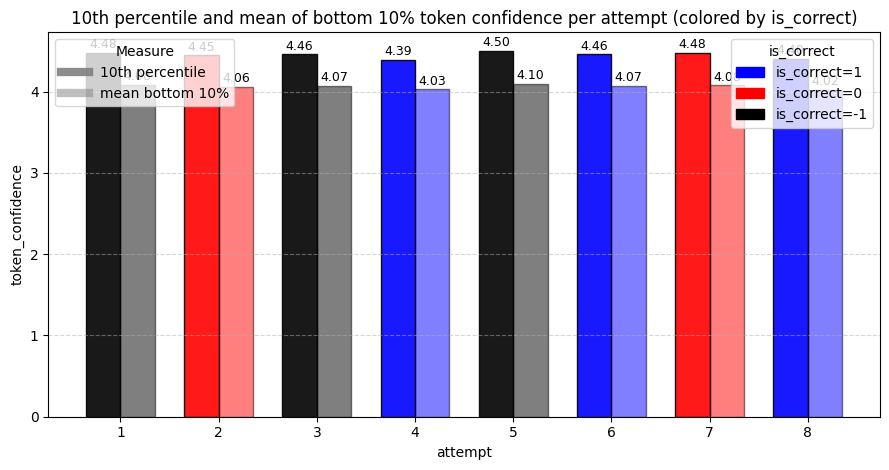


Per-attempt 10th-percentile and mean(bottom 10%) summary:
   attempt       p10  mean_bottom10    count  is_correct_mode  color
0        1  4.477329       4.082882  62048.0             -1.0  black
1        2  4.445256       4.056959  48647.0              0.0    red
2        3  4.457519       4.072773  63291.0             -1.0  black
3        4  4.392274       4.028696  19755.0              1.0   blue
4        5  4.504297       4.099345  62261.0             -1.0  black
5        6  4.460992       4.072475  55525.0              1.0   blue
6        7  4.477480       4.077272  60299.0              0.0    red
7        8  4.402552       4.024879  34489.0              1.0   blue


In [13]:
# 10th-percentile and mean of bottom 10% token confidence per attempt, colored by is_correct mode
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

# helper to compute mean of bottom fraction
def mean_bottom_frac(series, frac=0.1):
    n = max(1, int(np.floor(len(series) * frac)))
    return series.nsmallest(n).mean()

agg_p10 = df.groupby('attempt').apply(lambda g: pd.Series({
    'p10': g['token_confidence'].quantile(0.1),
    'mean_bottom10': mean_bottom_frac(g['token_confidence'], 0.1),
    'count': len(g),
    'is_correct_mode': int(g['is_correct'].mode().iloc[0]) if not g['is_correct'].mode().empty else 0
})).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_p10['color'] = agg_p10['is_correct_mode'].map(color_map).fillna('gray')

x = agg_p10['attempt'].values
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4.8))
# bars: left = 10th percentile, right = mean bottom 10%
ax.bar(x - width/2, agg_p10['p10'], width, color=agg_p10['color'], edgecolor='k', alpha=0.9)
ax.bar(x + width/2, agg_p10['mean_bottom10'], width, color=agg_p10['color'], edgecolor='k', alpha=0.5)

# annotate values
for _, row in agg_p10.iterrows():
    ax.text(row['attempt'] - width/2, row['p10'] + 0.02, f"{row['p10']:.2f}", ha='center', va='bottom', fontsize=9)
    ax.text(row['attempt'] + width/2, row['mean_bottom10'] + 0.02, f"{row['mean_bottom10']:.2f}", ha='center', va='bottom', fontsize=9)

# legends: measure types and is_correct colors
from matplotlib.lines import Line2D
measure_handles = [Line2D([0], [0], color='gray', lw=6, alpha=0.9, label='10th percentile'),
                   Line2D([0], [0], color='gray', lw=6, alpha=0.5, label='mean bottom 10%')]
color_handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
leg1 = ax.legend(handles=measure_handles, loc='upper left', title='Measure')
ax.add_artist(leg1)
ax.legend(handles=color_handles, loc='upper right', title='is_correct')

ax.set_xlabel('attempt')
ax.set_ylabel('token_confidence')
ax.set_title('10th percentile and mean of bottom 10% token confidence per attempt (colored by is_correct)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('p10_and_mean_bottom10_by_attempt_colored_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-attempt 10th-percentile and mean(bottom 10%) summary:')
print(agg_p10)

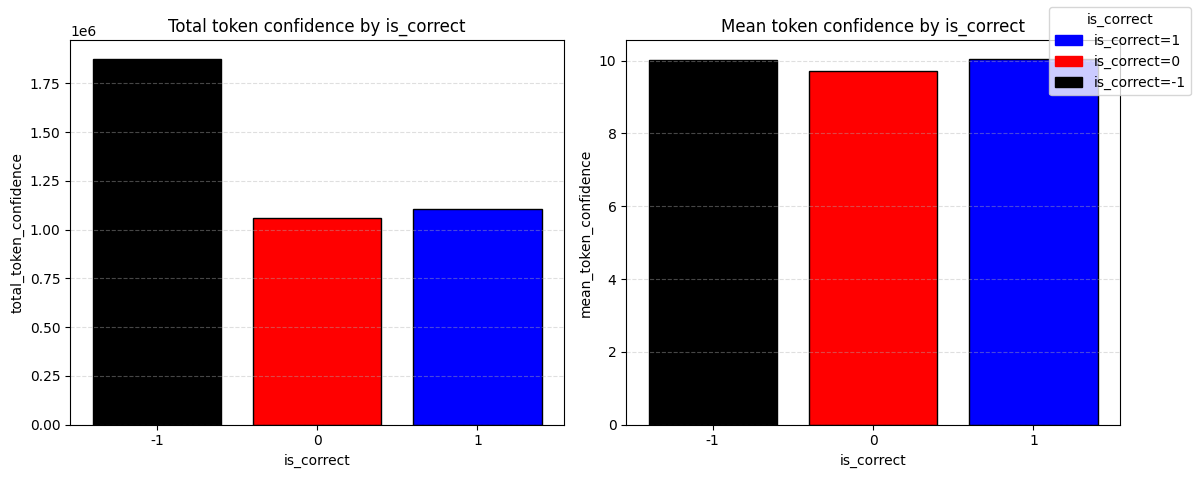


Aggregated by is_correct:
   is_correct    total_conf  mean_conf   count  color
0          -1  1.877152e+06  10.006140  187600  black
1           0  1.058376e+06   9.714682  108946    red
2           1  1.103775e+06  10.055433  109769   blue


In [14]:
# Group by `is_correct` and plot total and mean token confidence (colored by is_correct)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

agg_by_correct = df.groupby('is_correct').agg(
    total_conf=('token_confidence', 'sum'),
    mean_conf=('token_confidence', 'mean'),
    count=('token_confidence', 'count')
).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_by_correct['color'] = agg_by_correct['is_correct'].map(color_map).fillna('gray')

# Plot side-by-side bars: total_conf (left) and mean_conf (right)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Total confidence (may be large)
axes[0].bar(agg_by_correct['is_correct'].astype(str), agg_by_correct['total_conf'], color=agg_by_correct['color'], edgecolor='k')
axes[0].set_title('Total token confidence by is_correct')
axes[0].set_xlabel('is_correct')
axes[0].set_ylabel('total_token_confidence')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Mean confidence
axes[1].bar(agg_by_correct['is_correct'].astype(str), agg_by_correct['mean_conf'], color=agg_by_correct['color'], edgecolor='k')
axes[1].set_title('Mean token confidence by is_correct')
axes[1].set_xlabel('is_correct')
axes[1].set_ylabel('mean_token_confidence')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Shared legend for color mapping
handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
fig.legend(handles=handles, title='is_correct', loc='upper right')
plt.tight_layout(rect=[0, 0, 0.95, 1.0])
plt.savefig('total_and_mean_conf_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAggregated by is_correct:')
print(agg_by_correct)

C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\1307264480.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_info = df.groupby('is_correct').apply(lambda g: pd.Series({


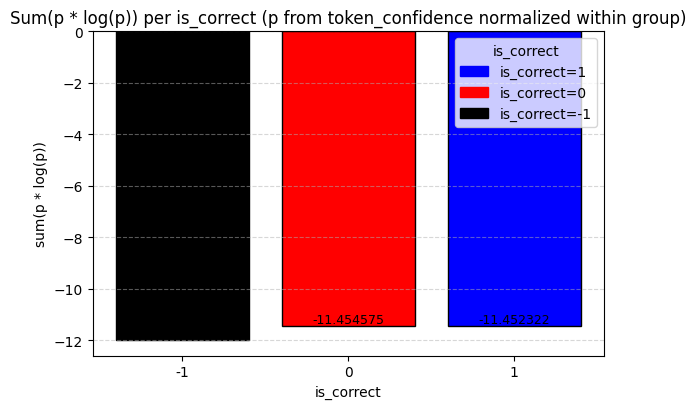


Sum(p*log(p)) by is_correct:
   is_correct  sum_p_log_p    total_conf     count  color
0          -1   -11.992635  1.877152e+06  187600.0  black
1           0   -11.454575  1.058376e+06  108946.0    red
2           1   -11.452322  1.103775e+06  109769.0   blue


In [15]:
# Compute sum(p * log(p)) per `is_correct` group (p from token_confidence normalized within group) and plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

def sum_p_log_p(group):
    vals = group['token_confidence'].astype(float)
    total = vals.sum()
    if total <= 0:
        return np.nan
    p = vals / total
    p = p[p > 0]
    return (p * np.log(p)).sum()

agg_info = df.groupby('is_correct').apply(lambda g: pd.Series({
    'sum_p_log_p': sum_p_log_p(g),
    'total_conf': g['token_confidence'].astype(float).sum(),
    'count': len(g)
})).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_info['color'] = agg_info['is_correct'].map(color_map).fillna('gray')

plt.figure(figsize=(6, 4.2))
plt.bar(agg_info['is_correct'].astype(str), agg_info['sum_p_log_p'], color=agg_info['color'], edgecolor='k')
for _, row in agg_info.iterrows():
    plt.text(str(row['is_correct']), row['sum_p_log_p'] + 1e-6, f"{row['sum_p_log_p']:.6f}", ha='center', va='bottom', fontsize=9)

plt.xlabel('is_correct')
plt.ylabel('sum(p * log(p))')
plt.title('Sum(p * log(p)) per is_correct (p from token_confidence normalized within group)')
handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('sum_p_log_p_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSum(p*log(p)) by is_correct:')
print(agg_info)


C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\799226251.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_p_log_p2 = df.groupby('is_correct').apply(lambda g: pd.Series({


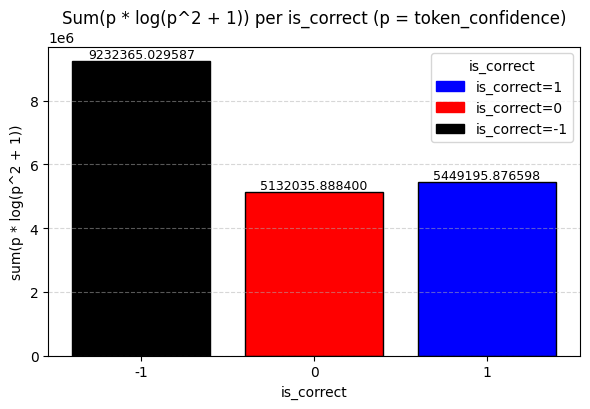


Sum p*log(p^2 + 1) by is_correct:
   is_correct  sum_p_log_p2_plus1    total_conf     count  color
0          -1        9.232365e+06  1.877152e+06  187600.0  black
1           0        5.132036e+06  1.058376e+06  108946.0    red
2           1        5.449196e+06  1.103775e+06  109769.0   blue


In [17]:
# Compute sum(p * log(p^2 + 1)) per `is_correct` group (p = token_confidence, no normalization) and plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

def sum_p_log_p2_plus1(group):
    vals = group['token_confidence'].astype(float)
    # compute p * log(p^2 + 1) — safe for negative/zero values
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.sum(vals * np.log(vals ** 2 + 1))

agg_p_log_p2 = df.groupby('is_correct').apply(lambda g: pd.Series({
    'sum_p_log_p2_plus1': sum_p_log_p2_plus1(g),
    'total_conf': g['token_confidence'].astype(float).sum(),
    'count': len(g)
})).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_p_log_p2['color'] = agg_p_log_p2['is_correct'].map(color_map).fillna('gray')

plt.figure(figsize=(6, 4.2))
plt.bar(agg_p_log_p2['is_correct'].astype(str), agg_p_log_p2['sum_p_log_p2_plus1'], color=agg_p_log_p2['color'], edgecolor='k')
for _, row in agg_p_log_p2.iterrows():
    plt.text(str(row['is_correct']), row['sum_p_log_p2_plus1'] + 1e-6, f"{row['sum_p_log_p2_plus1']:.6f}", ha='center', va='bottom', fontsize=9)

plt.xlabel('is_correct')
plt.ylabel('sum(p * log(p^2 + 1))')
plt.title('Sum(p * log(p^2 + 1)) per is_correct (p = token_confidence)')
handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('sum_p_log_p2_plus1_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSum p*log(p^2 + 1) by is_correct:')
print(agg_p_log_p2)


C:\Users\defaultuser0.LAPTOP-LRB3T941\AppData\Local\Temp\ipykernel_10908\2588621614.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_last10 = df.groupby('attempt').apply(lambda g: pd.Series({


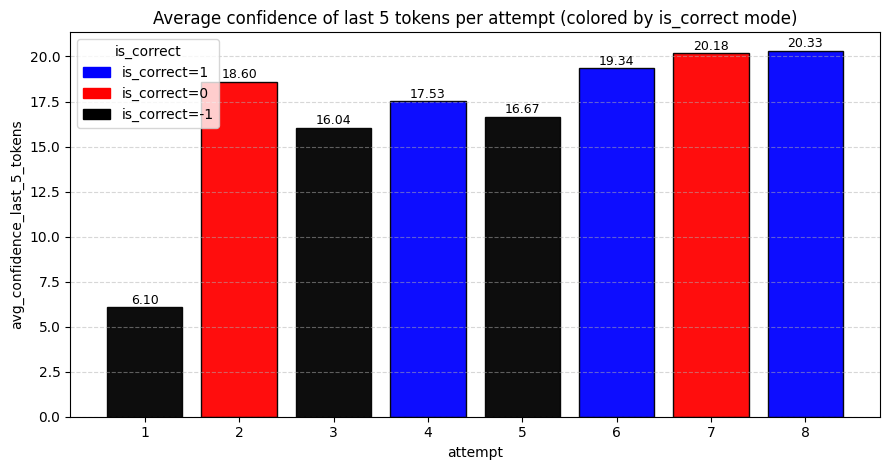


Average of last 5 tokens per attempt:
   attempt  avg_last10    count  is_correct_mode  color
0        1    6.097295  62048.0             -1.0  black
1        2   18.600418  48647.0              0.0    red
2        3   16.041428  63291.0             -1.0  black
3        4   17.529557  19755.0              1.0   blue
4        5   16.668458  62261.0             -1.0  black
5        6   19.338108  55525.0              1.0   blue
6        7   20.176030  60299.0              0.0    red
7        8   20.325469  34489.0              1.0   blue


In [26]:
# Average confidence of the last 10 tokens per attempt, colored by is_correct mode
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# use existing `data` loaded earlier
df = data.copy()

# For each attempt, take the last 5 tokens (highest token_index) and compute their mean confidence
agg_last10 = df.groupby('attempt').apply(lambda g: pd.Series({
    'avg_last10': g.sort_values('token_index', ascending=False).head(5)['token_confidence'].mean(),
    'count': len(g),
    'is_correct_mode': int(g['is_correct'].mode().iloc[0]) if not g['is_correct'].mode().empty else 0
})).reset_index()

color_map = {1: 'blue', -1: 'black', 0: 'red'}
agg_last10['color'] = agg_last10['is_correct_mode'].map(color_map).fillna('gray')

plt.figure(figsize=(9, 4.8))
plt.bar(agg_last10['attempt'], agg_last10['avg_last10'], color=agg_last10['color'], edgecolor='k', alpha=0.95)
for _, row in agg_last10.iterrows():
    plt.text(row['attempt'], row['avg_last10'] + 0.02, f"{row['avg_last10']:.2f}", ha='center', va='bottom', fontsize=9)

handles = [Patch(color=color_map[k], label=f'is_correct={k}') for k in sorted(color_map.keys(), reverse=True)]
plt.legend(handles=handles, title='is_correct')
plt.xlabel('attempt')
plt.ylabel('avg_confidence_last_5_tokens')
plt.title('Average confidence of last 5 tokens per attempt (colored by is_correct mode)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('avg_last5_by_attempt_colored_by_is_correct.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAverage of last 5 tokens per attempt:')
print(agg_last10)
